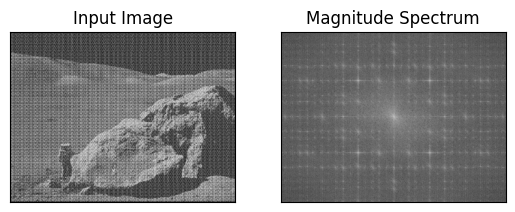

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
 
img = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)
 
dft = cv.dft(np.float32(img),flags = cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
 
magnitude_spectrum = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
 
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

In [2]:
#Filter creating
# Low pass filter
mask = np.zeros((img.shape[0],img.shape[1],2),np.uint8)
centerX, centerY = (int(img.shape[0] / 2),int(img.shape[1] / 2))
mask[centerX-50:centerX+50, centerY - 50:centerY+50,:] = 1

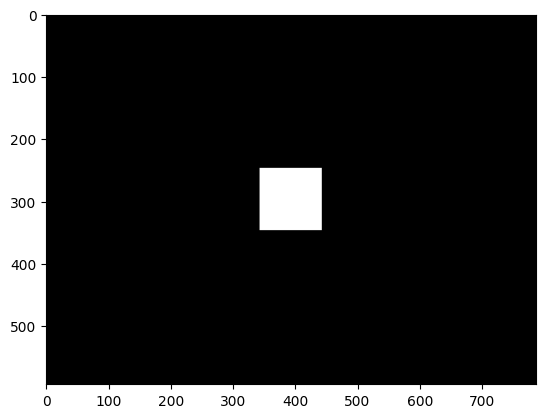

In [3]:
plt.imshow(mask[:,:,0], cmap = 'gray')

In [4]:
# Filtering
dft_shift = dft_shift*mask

C:\Users\kingf\AppData\Local\Temp\ipykernel_10088\3830399572.py:1: RuntimeWarning: divide by zero encountered in log
  filtering_magn_res = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))


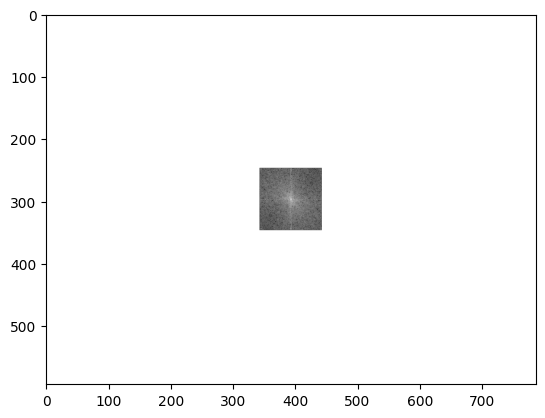

In [5]:
filtering_magn_res = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
plt.imshow(filtering_magn_res, cmap='gray')

In [6]:
#fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(dft_shift)
img_back = cv.idft(f_ishift)
img_back = cv.magnitude(img_back[:,:,0],img_back[:,:,1])

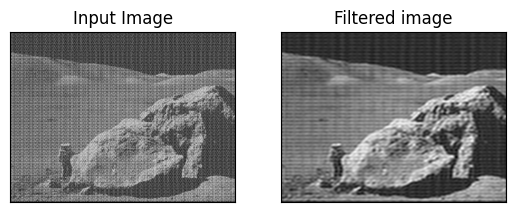

In [7]:
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_back, cmap = 'gray')
plt.title('Filtered image'), plt.xticks([]), plt.yticks([])
plt.show()

In [8]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
# Реализуйте удаление периодического шума

In [ ]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса

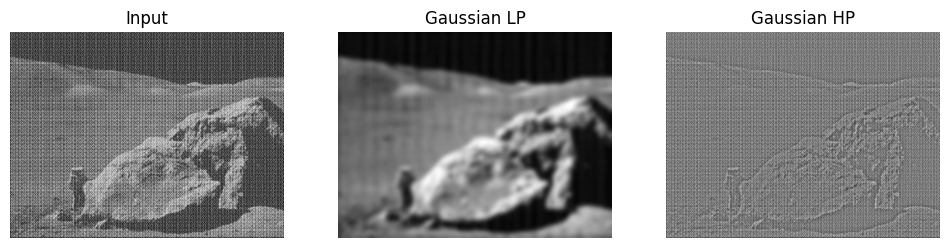

In [13]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def gaussian_high_pass_spatial(img, ksize=31, sigma=7.0):
    """
    Высокочастотная фильтрация в пространственной области через Гаусс:
    HP = img - GaussianBlur(img), с нормализацией в [0..255].
    """
    img_f = img.astype(np.float32)
    low = cv.GaussianBlur(img_f, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)
    high = img_f - low

    # Для просмотра удобно привести к 0..255
    high_vis = cv.normalize(high, None, 0, 255, cv.NORM_MINMAX)
    return high, high_vis.astype(np.uint8), low.astype(np.uint8)

# Пример использования:
img = cv.imread("periodic_noise.jpg", cv.IMREAD_GRAYSCALE)
high, high_vis, low = gaussian_high_pass_spatial(img, ksize=31, sigma=7.0)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Input"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(low, cmap="gray"); plt.title("Gaussian LP"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(high_vis, cmap="gray"); plt.title("Gaussian HP"); plt.axis("off")
plt.show()


In [10]:
# Реализуйте удаление периодического шума

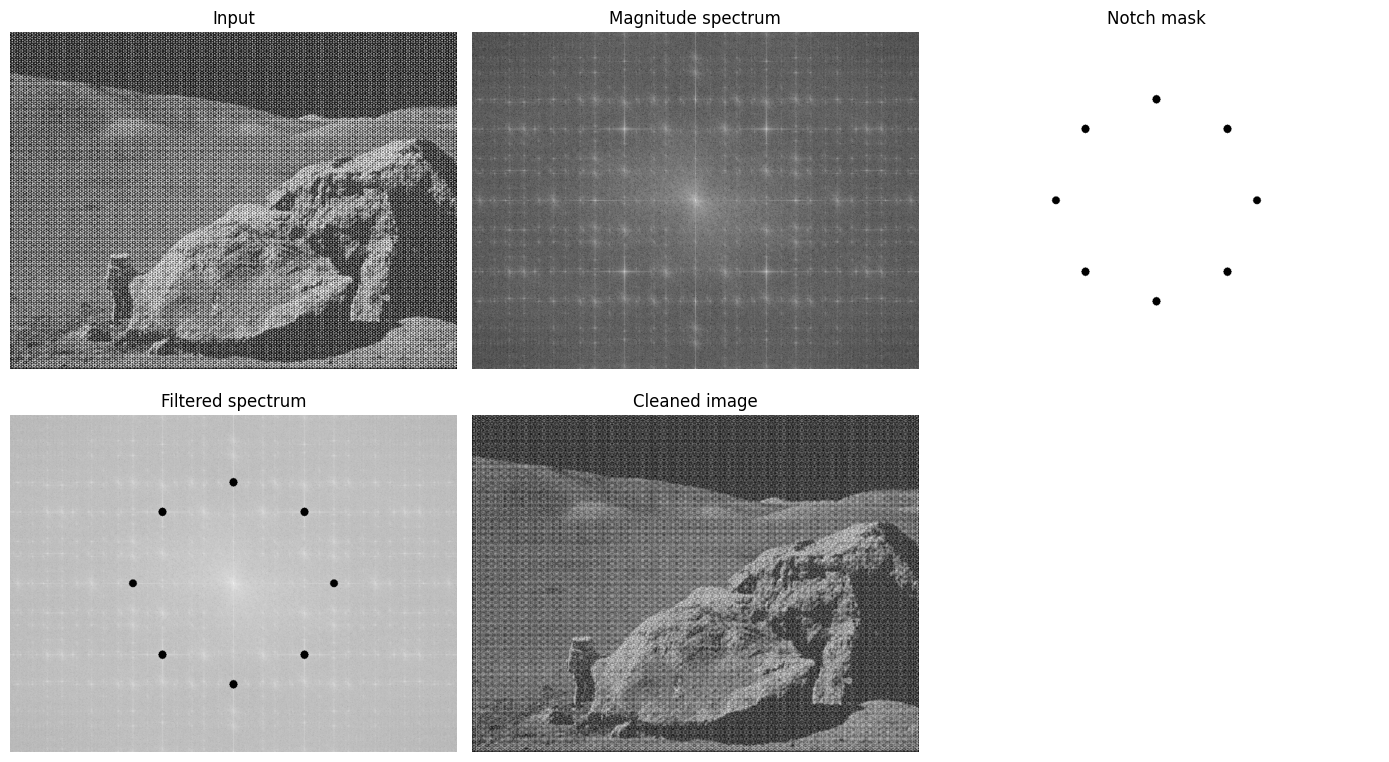

Найденные пики (x,y): [(570, 297), (216, 297), (268, 422), (518, 172), (518, 422), (268, 172), (393, 474), (393, 120), (393, 119), (393, 475), (268, 171), (518, 423), (518, 171), (268, 423)]


In [12]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def dft2(img):
    dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    return dft_shift

def idft2(dft_shift):
    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = cv.idft(f_ishift)
    img_back = cv.magnitude(img_back[:,:,0], img_back[:,:,1])
    img_back = cv.normalize(img_back, None, 0, 255, cv.NORM_MINMAX)
    return img_back.astype(np.uint8)

def magnitude_spectrum(dft_shift):
    mag = cv.magnitude(dft_shift[:,:,0], dft_shift[:,:,1])
    mag = 20*np.log(mag + 1e-8)  # +eps чтобы не было divide by zero
    return mag

def notch_reject_mask(shape, centers, r=6):
    H, W = shape
    mask = np.ones((H, W), np.uint8)
    yy, xx = np.ogrid[:H, :W]
    for (x, y) in centers:
        dist2 = (xx - x)**2 + (yy - y)**2
        mask[dist2 <= r*r] = 0
    return mask

def auto_find_peaks(mag, top_k=12, center_radius=20, thresh_percent=99.5):
    H, W = mag.shape
    cy, cx = H//2, W//2

    mag2 = mag.copy()
    rr = center_radius
    mag2[cy-rr:cy+rr, cx-rr:cx+rr] = 0

    t = np.percentile(mag2, thresh_percent)
    ys, xs = np.where(mag2 >= t)

    if len(xs) > top_k:
        vals = mag2[ys, xs]
        idx = np.argsort(vals)[::-1][:top_k]
        xs, ys = xs[idx], ys[idx]

    # вернем список центров (x,y)
    return list(zip(xs.tolist(), ys.tolist()))

img = cv.imread("periodic_noise.jpg", cv.IMREAD_GRAYSCALE)

F = dft2(img)
mag = magnitude_spectrum(F)

peaks = auto_find_peaks(mag, top_k=14, center_radius=25, thresh_percent=99.7)
mask2d = notch_reject_mask(img.shape, peaks, r=7)

mask = np.repeat(mask2d[:, :, None], 2, axis=2)

F_filt = F * mask
img_clean = idft2(F_filt)

plt.figure(figsize=(14,8))
plt.subplot(2,3,1); plt.imshow(img, cmap="gray"); plt.title("Input"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(mag, cmap="gray"); plt.title("Magnitude spectrum"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(mask2d, cmap="gray"); plt.title("Notch mask"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(magnitude_spectrum(F_filt), cmap="gray"); plt.title("Filtered spectrum"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(img_clean, cmap="gray"); plt.title("Cleaned image"); plt.axis("off")
plt.tight_layout()
plt.show()

print("Найденные пики (x,y):", peaks)
